## **Cosine similarity of Care**

In [1]:
# @title Installazione librerie
!pip install -q transformers datasets accelerate sentence-transformers scikit-learn pandas matplotlib tqdm

In [2]:
import torch
print("GPU disponibile:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


GPU disponibile: True
Device: Tesla T4


In [3]:
from google.colab import files
uploaded = files.upload()  # carica il tuo corpus.csv
corpus_filename = list(uploaded.keys())[0]
print("File caricato:", corpus_filename)

Saving articles-ssh.csv to articles-ssh (1).csv
File caricato: articles-ssh (1).csv


In [4]:
import pandas as pd

df = pd.read_csv(corpus_filename)
print("Numero di documenti nel corpus:", len(df))
df.head()

# --- Configura qui i nomi delle colonne del TUO file ---
TEXT_COL = "Abstract"         # colonna con il testo da analizzare (abstract o full text)
YEAR_COL = "Publication Year" # opzionale: colonna con l'anno (per analisi diacronica). Metti None se assente.
ID_COL   = "Key"               # opzionale: identificativo univoco. Metti None se assente.

assert TEXT_COL in df.columns, f"Colonna '{TEXT_COL}' non trovata. Colonne disponibili: {list(df.columns)}"

df = df.dropna(subset=[TEXT_COL]).reset_index(drop=True)
print("Documenti con testo non nullo:", len(df))


Numero di documenti nel corpus: 3134
Documenti con testo non nullo: 3042


In [5]:
import re

TARGET_LEMMAS = ["care", "cares", "caring", "cared"]  # estendi se vuoi includere "care-full", "carefully", ecc.

def find_occurrences(text, doc_id, year=None):
    occurrences = []
    # split approssimativo in frasi
    sentences = re.split(r'(?<=[.!?])\s+', str(text))
    for sent in sentences:
        for lemma in TARGET_LEMMAS:
            if re.search(rf'\b{lemma}\b', sent, flags=re.IGNORECASE):
                occurrences.append({
                    "doc_id": doc_id,
                    "year": year,
                    "sentence": sent.strip(),
                    "lemma_found": lemma
                })
                break
    return occurrences

all_occurrences = []
for idx, row in df.iterrows():
    doc_id = row[ID_COL] if ID_COL and ID_COL in df.columns else idx
    year = row[YEAR_COL] if YEAR_COL and YEAR_COL in df.columns else None
    all_occurrences.extend(find_occurrences(row[TEXT_COL], doc_id, year))

occ_df = pd.DataFrame(all_occurrences)
print(f"Trovate {len(occ_df)} occorrenze di 'care' in {occ_df['doc_id'].nunique()} documenti su {len(df)} totali.")
occ_df.head()


Trovate 3566 occorrenze di 'care' in 2615 documenti su 3042 totali.


,doc_id,year,sentence,lemma_found
0,BU3H5Q6T,2018.0,"For this, first of all, the creation of a deve...",care
1,2KLDI2KY,2021.0,"In 1767, Pallas was commissioned by the Academ...",care
2,ZBWS9JVH,2022.0,It is the subject of the disabled people and t...,care
3,V3TUBABS,2023.0,"In contrast, the presence of the traditions of...",care
4,9QZVT35K,2025.0,The article calls for faith and culturally sen...,care


In [6]:
# Import completi e autonomi: questa cella funziona sia se hai fatto il fine-tuning (Sezione 3)
# sia se l'hai saltato e usi direttamente bert-base-uncased.
from transformers import BertTokenizerFast, BertModel
import torch
import numpy as np
from tqdm.auto import tqdm

# Se hai eseguito la Sezione 3, SAVE_PATH esiste gia' e punta al modello fine-tunato.
# Se l'hai saltata, questa cella usa automaticamente il modello base pre-addestrato.
try:
    MODEL_PATH = SAVE_PATH
    print("Uso il modello fine-tunato:", MODEL_PATH)
except NameError:
    MODEL_PATH = "bert-base-uncased"
    print("Sezione 3 saltata: uso il modello base pre-addestrato:", MODEL_PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = BertTokenizerFast.from_pretrained(MODEL_PATH)
embed_model = BertModel.from_pretrained(MODEL_PATH, output_hidden_states=True)
embed_model.eval()
embed_model.to(device)

def get_contextual_embedding(sentence, target_lemmas=TARGET_LEMMAS):
    """Ritorna l'embedding contestuale del token target in una frase,
    sommando gli ultimi 4 layer nascosti (come nel paper)."""
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True, max_length=128).to(device)
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    target_idx = None
    for i, tok in enumerate(tokens):
        clean_tok = tok.replace("##", "")
        if any(lemma in clean_tok.lower() for lemma in target_lemmas):
            target_idx = i
            break
    if target_idx is None:
        return None

    with torch.no_grad():
        outputs = embed_model(**inputs)
    hidden_states = outputs.hidden_states  # tuple di (num_layers+1) tensori [1, seq_len, 768]
    last4 = torch.stack(hidden_states[-4:])       # [4, 1, seq_len, 768]
    summed = last4.sum(dim=0)                      # [1, seq_len, 768]
    token_embedding = summed[0, target_idx].cpu().numpy()
    return token_embedding

# Estrai le embedding per tutte le occorrenze (puo' richiedere tempo su corpus grandi)
embeddings = []
valid_rows = []
for idx, row in tqdm(occ_df.iterrows(), total=len(occ_df)):
    emb = get_contextual_embedding(row["sentence"])
    if emb is not None:
        embeddings.append(emb)
        valid_rows.append(idx)

occ_df = occ_df.loc[valid_rows].reset_index(drop=True)
care_embeddings = np.vstack(embeddings)
print("Embedding estratte:", care_embeddings.shape)


Sezione 3 saltata: uso il modello base pre-addestrato: bert-base-uncased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/3566 [00:00<?, ?it/s]

Embedding estratte: (3559, 768)


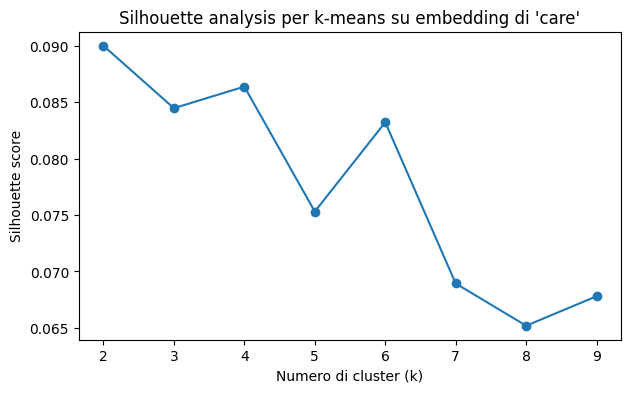

k ottimale secondo silhouette analysis: 2


In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

sil_scores = {}
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(care_embeddings)
    sil_scores[k] = silhouette_score(care_embeddings, labels)

plt.figure(figsize=(7,4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o')
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette analysis per k-means su embedding di 'care'")
plt.show()

best_k = max(sil_scores, key=sil_scores.get)
print(f"k ottimale secondo silhouette analysis: {best_k}")


In [8]:
km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
occ_df["cluster"] = km.fit_predict(care_embeddings)

# Ispeziona alcune frasi rappresentative per ciascun cluster
for c in sorted(occ_df["cluster"].unique()):
    print(f"\n--- Cluster {c} (n={sum(occ_df['cluster']==c)}) ---")
    sample = occ_df[occ_df["cluster"] == c].sample(min(5, sum(occ_df['cluster']==c)), random_state=1)
    for s in sample["sentence"]:
        print(" -", s[:200])



--- Cluster 0 (n=1529) ---
 - Topics included in this compilation include pharmaceutical contaminants in the New Zealand environment; environmental sustainability in Australia; the electricity distribution industry in New Zealand;
 - The World Health Organization, health-care professionals, and public equate good health not merely to the absence of disease, but also to the presence of positive well-being.
 - In recent years, gardening has spread in European Early Childhood Education and Care centres through projects and specific programs with a developmental, educational and inclusive focus.
 - A strong sense of professional identity is key to staff retention and recruitment and key to the delivery of quality nursing care.
 - On the other hand, the anti-trash fight of the worker's youth movement can only be properly understood within the context of a disassociation from bourgeois and confessional supervisory youth care.

--- Cluster 1 (n=2030) ---
 - In 2019, the charity English Herit

In [9]:
!pip install -q spacy
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 107.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [11]:
import spacy
from collections import Counter

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])  # solo tokenizzazione + POS, per velocita'
nlp.add_pipe("sentencizer")  # il parser (disabilitato sopra) e' cio' che normalmente segmenta le frasi:
                              # senza parser serve un sentencizer leggero al suo posto per usare doc.sents

TOP_N_VOCAB = 300        # quanti sostantivi candidati considerare (i piu' frequenti nel corpus)
MAX_OCC_PER_WORD = 30     # quante frasi campionare per ciascun sostantivo candidato (compromesso tempo/qualita')

EXCLUDE_LEMMAS = set(TARGET_LEMMAS) | {"care"}  # non ha senso confrontare "care" con se stesso

# --- 1. Estrai tutti i sostantivi (lemmatizzati) dal corpus con la loro frequenza ---
noun_counter = Counter()
sample_sentences_by_noun = {}  # lemma -> lista di frasi in cui compare

all_texts = df[TEXT_COL].astype(str).tolist()

for text in tqdm(all_texts, desc="POS tagging corpus"):
    doc = nlp(text)
    for sent in doc.sents:
        sent_text = sent.text.strip()
        seen_in_sentence = set()
        for token in sent:
            if token.pos_ == "NOUN" and token.is_alpha and not token.is_stop:
                lemma = token.lemma_.lower()
                if lemma in EXCLUDE_LEMMAS or len(lemma) < 3:
                    continue
                noun_counter[lemma] += 1
                if lemma not in seen_in_sentence:
                    sample_sentences_by_noun.setdefault(lemma, []).append(sent_text)
                    seen_in_sentence.add(lemma)

print(f"Sostantivi unici individuati nel corpus: {len(noun_counter)}")
candidate_vocab = [w for w, _ in noun_counter.most_common(TOP_N_VOCAB)]
print(f"Vocabolario candidato (top {TOP_N_VOCAB} per frequenza):", candidate_vocab[:20], "...")


POS tagging corpus:   0%|          | 0/3042 [00:00<?, ?it/s]

Sostantivi unici individuati nel corpus: 10221
Vocabolario candidato (top 300 per frequenza): ['heritage', 'museum', 'study', 'community', 'research', 'practice', 'collection', 'health', 'people', 'work', 'article', 'conservation', 'paper', 'development', 'value', 'approach', 'right', 'site', 'art', 'object'] ...


In [12]:
# --- 2. Per ciascun sostantivo candidato, estrai embedding contestuali campionate e calcola la similarita' con 'care' ---
from sklearn.metrics.pairwise import cosine_similarity
import random

random.seed(42)
care_vector = care_embeddings.mean(axis=0, keepdims=True)  # vettore aggregato di 'care' (dalla Sezione 4)

word_similarities = {}
for word in tqdm(candidate_vocab, desc="Calcolo similarita' per vocabolario"):
    sentences = sample_sentences_by_noun.get(word, [])
    if not sentences:
        continue
    sampled = random.sample(sentences, min(MAX_OCC_PER_WORD, len(sentences)))
    embs = []
    for sent in sampled:
        emb = get_contextual_embedding(sent, target_lemmas=[word])
        if emb is not None:
            embs.append(emb)
    if embs:
        word_vector = np.vstack(embs).mean(axis=0, keepdims=True)
        sim = cosine_similarity(care_vector, word_vector)[0][0]
        word_similarities[word] = sim

nn_df = pd.DataFrame(sorted(word_similarities.items(), key=lambda x: -x[1]), columns=["term", "cosine_similarity"])
print(f"Similarita' calcolata per {len(nn_df)} termini.")
nn_df.head(25)


Calcolo similarita' per vocabolario:   0%|          | 0/300 [00:00<?, ?it/s]

Similarita' calcolata per 298 termini.


,term,cosine_similarity
0,treatment,0.809784
1,service,0.743429
2,management,0.729360
3,intervention,0.728928
4,maintenance,0.727906
5,protection,0.724373
6,healthcare,0.721821
7,support,0.705056
8,control,0.703663
9,hospital,0.701586


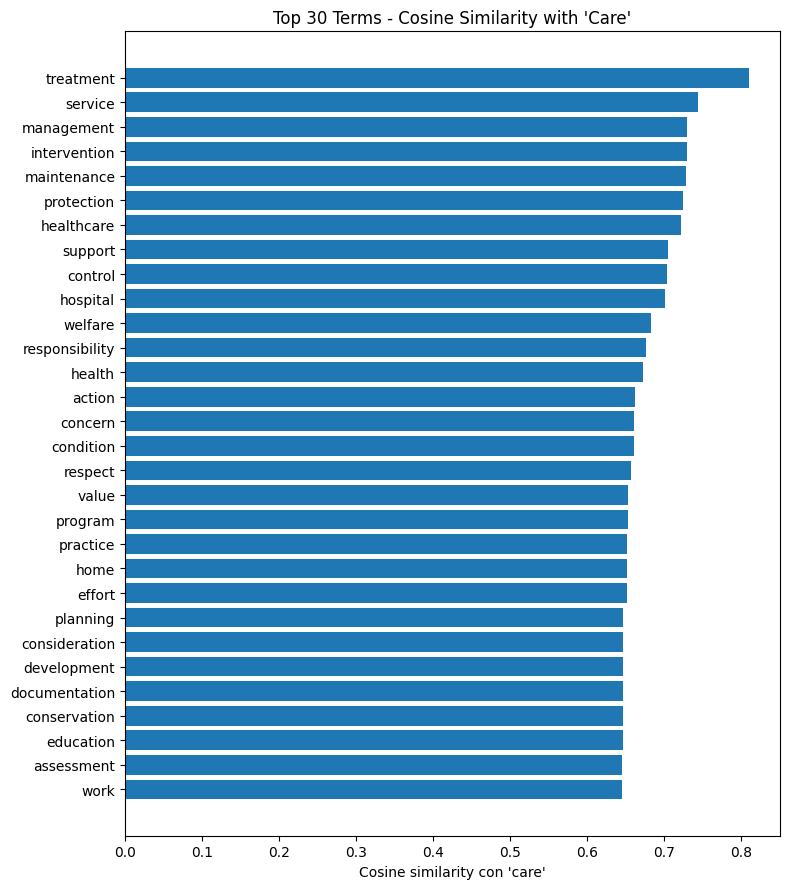

In [17]:
# --- 3. Visualizzazione: i termini emergono da soli, non li abbiamo scelti noi ---
TOP_N_DISPLAY = 30

top_terms = nn_df.head(TOP_N_DISPLAY)

plt.figure(figsize=(8, 9))
plt.barh(top_terms["term"][::-1], top_terms["cosine_similarity"][::-1])
plt.xlabel("Cosine similarity con 'care'")
plt.title(f"Top {TOP_N_DISPLAY} Terms - Cosine Similarity with 'Care'")
plt.tight_layout()
plt.show()

nn_df.to_csv("/content/care_nearest_neighbors.csv", index=False)
